## NBA 2025 Playoffs: Offensive Efficiency vs Offensive Creation (Top Scorers Analysis)

This project analyzes the top 50 NBA playoff scorers from the 2025 postseason to evaluate offensive performance through scoring efficiency under volume and overall offensive creation.

## Data Source

All data used in this project was collected from publicly available NBA box score statistics (NBA.com). It includes player-level performance metrics such as points, field goal attempts, shooting percentages, assists, turnovers, and other advanced efficiency indicators.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("NBA Data Analysis Statistics(Top 50 Scorers 24-25 Playoffs).csv")


In [11]:
df.columns = df.columns.str.strip()
df = df[df["Player"] != "Player"]
# Reset index
df = df.reset_index(drop=True)

# Convert to numbers
df["FGA"] = pd.to_numeric(df["FGA"])
df["FG%"] = pd.to_numeric(df["FG%"])
df["PTS"] = pd.to_numeric(df["PTS"])

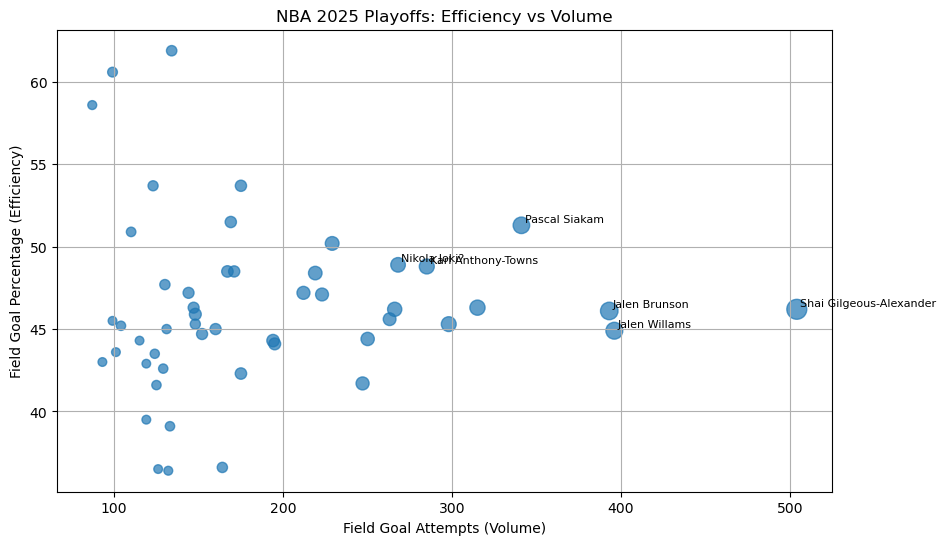

In [33]:
# Create scatter plot
plt.figure(figsize=(10,6))

plt.scatter(
    df["FGA"],        # volume
    df["FG%"],        # efficiency
    s=df["PTS"] * 0.3,  # size = scoring
    alpha=0.7
)

# Label top scorers
for _, row in df.iterrows():
    if (
    row["PTS"] > 400
    or (row["FGA"] > 300 and row["FG%"] > 48)
    or (row["FGA"] > 250 and row["FG%"] > 48.5)
):
        plt.text(row["FGA"] + 2, row["FG%"] + 0.2, row["Player"], fontsize=8)
        
# Titles and labels
plt.xlabel("Field Goal Attempts (Volume)")
plt.ylabel("Field Goal Percentage (Efficiency)")
plt.title("NBA 2025 Playoffs: Efficiency vs Volume")

plt.grid(True)
plt.show()

The x-axis (FGA - Field Goals Attempted) is showing how much a player shoots, the y-axis (FG% - Field Goal Percentage) shows how efficient they are. The respective bubble size shows how much they score overall. We are answering who scores a lot and efficiently. 

The scatter plot is identifying the players who combine high volume with solid-to-high efficiency, labeling Shai Gilgeous-Alexander, Jalen Brunson, Jalen Williams, Pascal Siakam, Nikola Jokić, and Karl Anthony-Towns as the players who sustained scoring responsibility and did not fall apart efficiency-wise. This indicates that these players are primary offensive engines, taking many shots and maintaining respectable efficiency under pressure. However, this model does not conclude that they are the "best players" but are the best high-usage scorers in the playoffs.

This model has some distinctive strengths. This model effectively identifies players who maintain efficiencies despite taking on a high offensive burden. By incorporating shot volume (FGA), it highlights how difficult it is to sustain efficiency while being the primary scoring option. Players who appear in the top-right of the plot show efficiency under pressure which is an important indicator of scoring ability in a playoff context. Another key strength of this model is its ability to exclude players who appear efficient due to a lower shot volume. High FG% can be misleading when achieved on limited shot attempts, typically from players taking closer shots to the basket (usually power forwards and centers). By requiring both volume and production, the model ensures that only players with both high volume and production are highlighted, making the results more representative of meaningful scoring. Lastly, the model avoids a common mistake of valuing either efficiency or scoring volume in isolation by forcing a trade-off between the two. Players must demonstrate both high shot volume and efficiency to stand out, which naturally isolates elite scorers. This balance provides a more complete picture of scoring performance and prevents overvaluing inefficient high scorers or low-volume efficient players.

However, this model also contains limitations, resulting in uncertainties in making accurate assumptions and associations. While the model uses FG% as a measure of efficiency, it does not account for the differing values of shot types. Three-point shots and free throws are not weighted appropriately, distorting true scoring efficiency. As a result, players who generate a significant portion of their scoring from beyond the arc or the free throw line may not be accurately represented. Additionally, the model focuses solely on scoring metrics, overlooking a player's ability to create opportunities for their teammates. This is particularly evident when comparing Nikola Jokić and Karl Anthony-Towns, who appear similarly positioned on the plot due to comparable scoring volume and efficiency. However, Jokić's role as a primary facilitator, seen with his 112 assists in the playoffs, means his overall offensive impact moves beyond scoring. By not accounting for playmaking, the model treats these players as almost equivalent, when in reality their contributions to the team offense are fundamentally different. Lastly, by incorporating total points as a visual variable, the model introduces a bias toward players who have played more games or accumulated more minutes. This can inflate the perceived impact of certain players while undervaluing those with strong single-game or single-possession efficiency. As a result, the model may not fully capture true performance efficiency independent of playing time. 

A more complete version of this model would be to replace FG% with a possession-based efficiency metric and introduce playmaking variables to capture total offensive influence rather than scoring alone.

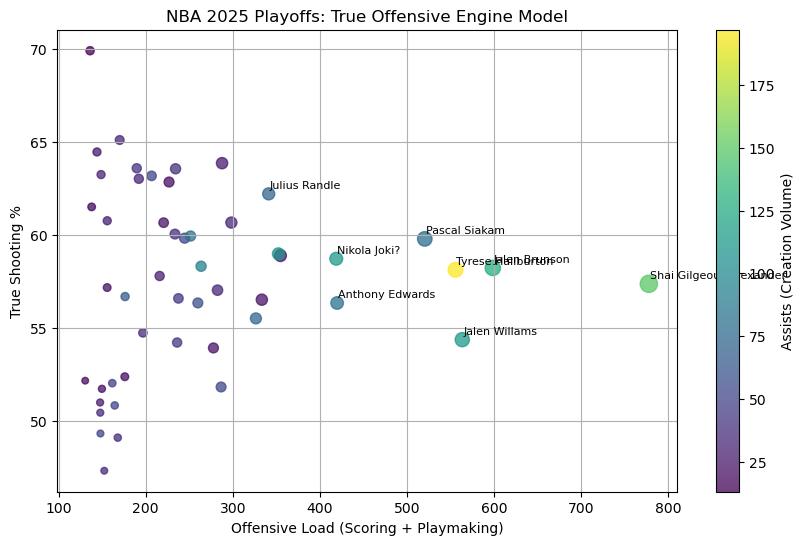

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# TRUE SHOOTING %
df["TS%"] = df["PTS"] / (2 * (df["FGA"] + 0.44 * df["FTA"])) * 100

# USAGE VOLUME (normalize scoring load)
df["Usage_Score"] = df["PTS"] + 1.2 * df["AST"] - 1.5 * df["TOV"]

# EFFICIENCY BONUS (non-linear so elites pop)
df["Efficiency_Bonus"] = (df["TS%"] / df["TS%"].mean()) ** 1.3

# OFFENSIVE IMPACT INDEX
df["Offensive_Impact"] = df["Usage_Score"] * df["Efficiency_Bonus"]

# PLOT: REAL OFFENSIVE ENGINE MODEL
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df["Usage_Score"],
    df["TS%"],
    s=df["Offensive_Impact"] * 0.2,
    c=df["AST"],
    cmap="viridis",
    alpha=0.75
)

# Label true offensive engines
for _, row in df.iterrows():
    if (
        row["Offensive_Impact"] > df["Offensive_Impact"].quantile(0.85)
    ):
        plt.text(
            row["Usage_Score"] + 1,
            row["TS%"] + 0.3,
            row["Player"],
            fontsize=8
        )

plt.xlabel("Offensive Load (Scoring + Playmaking)")
plt.ylabel("True Shooting %")
plt.title("NBA 2025 Playoffs: True Offensive Engine Model")

plt.colorbar(scatter, label="Assists (Creation Volume)")
plt.grid(True)
plt.show()

The playoff NBA playoff offensive model highlights a clear contrast between two dominant offensive archetypes: high-volume scorers and high-creation offensive engines. The model is built using points, shooting efficiency (TS%), assists, and turnovers to evaluate how much a player scores, how much offensive responsibility they carry, and how effectively they turn that responsibility into production. Within this framework, SGA and Haliburton sit near the top of the data set, but for fundamentally different reasons. 

Shai Gilgeous-Alexander leads all players in raw offensive production with 688 points across 23 games, averaging elite scoring volume on 504 field goal attempts. He combines this with solid efficiency (46.2 FG% and strong free throw production at 87.6%), showing that his offensive value is rooted in consistent self-generated scoring. His 150 assists indicate secondary playmaking, but his 60 turnovers reflect the reality of a high-usage role where he is constantly creating under defensive pressure. In this model, SGA represents offensive stability through scoring where even when possessions break down, he remains capable of producing points independently, making him a highly scalable playoff scorer.

Tyrese Haliburton represents a different type of offensive value entirely. While he scores less than SGA at 399 points, his impact is defined by creation. He leads the entire data set with 197 assists while maintaining efficient shooting (46.3 FG% and 34% from three-point range) and a relatively controlled 53 turnovers given his offensive workload. Haliburton's role is not centered on finishing possessions but organizing them. Indiana's offense flows through him, and his ability to generate assists at volume while maintaining efficiency makes him one of the clearest "offensive engine" profiles in the data set. However, his lower scoring output compared to SGA highlights a structural dependency where his value is maximized only when the system around is fully functional and vice versa. 

This difference becomes more significant in the context of the Finals and Haliburton's injury. When Haliburton is healthy, Indiana operates as a movement-heavy, pass-driven system that produces high-quality shots though constant ball circulation. When he is removed, that system loses its primary decision-maker, and the offense becomes far less structured. This exposes one of the key findings of the model, demonstrating that engine-driven offenses can reach extremely high levels of efficiency, but they are more sensitive to disruption because so much of the offensive identity is centralized in one player. 

By contrast, Oklahoma City's structure around SGA is more distributed. While he is clearly the primary scorer, the presence of Jalen Williams as a secondary creator, along with additional support from players like Chet Holmgren and Alex Caruso, reduces over-reliance on a single offensive organizer. This creates a different type of resilience. Even when SGA is heavily guarded, the Thunder can still score points, through secondary actions and complementary roles. In this sense, SGA operates as the focal point of a system, but not the sole source of their offensive structure. 

The comparison between these two players show a trade-off in modern NBA offense. Scoring-centric stars like SGA offer reliability in playoff settings because they consistently generate offense regardless of system flow or teammate performance. Engine-centric stars like Haliburton, on the other hand, maximize team-wide efficiency and elevate role players through passing and structure, but they are more dependent on continuity and health to function at their peak.

This leads to a more nuanced conclusion about championship construction. The Thunder's success suggests that having an elite scorer supported by a strong secondary system may provide greater stability across a playoff series. However, Haliburton's impact shows that engine-driven offenses can produce higher levels of collective offensive quality when fully intact. The issue, although, is not effectiveness, but fragility if the engine is removed as it is most likely that the offense will collapse.

For the league, this reflects an ongoing evolution in offensive identity. Teams are increasingly forced to choose between two models: building around a self-sufficient scorer who guarantees a baseline level of production, or building around a pass-first engine who maximizes system-wide efficiency. The data suggests neither approach is universally superior as each carries different risks. Scorers reduce variance and stabilize playoff performance while engines increase offensive ceiling but raise dependency risk. 

Ultimately, the model suggests that the most successful direction for the NBA is not choosing between scoring and creation, but combining both in a way that reduces dependency on any single player type. The ideal modern offense likely includes a primary scorer who can generate points under pressure, supported by one or more secondary creators who maintain structure and efficiency. SGA and Haliburton represent the two ends of the spectrum, and the contrast between them shows both the strategic trade-offs and future direction of the league.